[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josterri/predicting-the-next-words-notebooks/blob/main/ch08_workbook.ipynb)

# The transformer architecture

Attention weighs the positions it may read by the similarity of their keys to
a query, and without a positional encoding added to each input it cannot tell
the order of those positions. A causal mask limits each position to itself and
the positions before it; residual connections keep the gradient from vanishing
as blocks stack, and layer normalisation limits its growth.

In [1]:
#@title Setup: run this cell first
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

WORDS = ("it", "is", "a", "truth", "universally", "acknowledged")
D_MODEL = 64  # dimensions of an encoding, and the width of a block
BASE = 10000  # Vaswani et al. 2017, section 3.5: PE(pos, 2i) = sin(pos / 10000^(2i/d_model))
N_POS = 128  # positions 0 to 127, as in the lecture's figure of the encoding
TOL = 0.1
DEPTH = 12
SETUPS = {(False, False): "neither", (False, True): "layer norm alone",
          (True, False): "residual alone", (True, True): "residual and layer norm"}
rng = np.random.default_rng(0)
Q, K = rng.standard_normal((2, len(WORDS), 16))  # 16 components each
X0, G = rng.standard_normal((2, D_MODEL))
W1 = rng.standard_normal((DEPTH, 256, D_MODEL)) / np.sqrt(D_MODEL)
W2 = rng.standard_normal((DEPTH, D_MODEL, 256)) / np.sqrt(256)
EYE = np.eye(D_MODEL)


# A setting a cell refuses: Colab prints the one sentence, without the stack.
class Refused(Exception):
    _render_traceback_ = lambda self: [str(self)]  # noqa: E731


def need(ok, name, value, rule):
    if not ok:
        big = isinstance(value, int) and abs(value) > 10 ** 40  # repr fails past 4,300 digits
        shown = "a number of more than 40 digits" if big else repr(value)[:40]
        raise Refused(f"{name} is {shown}, of type {type(value).__name__}: {rule}.")
    return value


def switch(value, name):
    return bool(need(isinstance(value, (bool, np.bool_)), name, value, "it must be True or False"))


# Positions print without a thousands comma, since 100,000 typed in Python is the pair (100, 0).
def whole(value, name, hi):
    ok = isinstance(value, (int, np.integer)) and not isinstance(value, bool) and 0 <= value <= hi
    return int(need(ok, name, value, f"it must be a whole number from 0 to {hi}"))


# softmax((Q Kᵀ + M) / √d_k) row by row, M holding −∞ above the diagonal when mask is True.
def weights(mask):
    M = np.triu(np.full((len(WORDS), len(WORDS)), -np.inf), 1) if mask else 0
    s = (Q @ K.T + M) / np.sqrt(Q.shape[1])
    z = np.exp(s - s.max(axis=1, keepdims=True))
    return z / z.sum(axis=1, keepdims=True)


# White on a cell darker than relative luminance 0.179, where white and black have equal contrast.
def ink(rgba):
    lin = [c / 12.92 if c <= 0.04045 else ((c + 0.055) / 1.055) ** 2.4 for c in rgba[:3]]
    return "white" if 0.2126 * lin[0] + 0.7152 * lin[1] + 0.0722 * lin[2] < 0.179 else "black"


def show_weights(mask):
    mask = switch(mask, "MASK")
    fig, ax = plt.subplots(figsize=(6, 3.5))
    im = ax.imshow(weights(mask), cmap="Blues", vmin=0, vmax=1)
    fig.colorbar(im, ax=ax, label="attention weight")
    for (i, j), v in np.ndenumerate(weights(mask)):
        if mask and j > i:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, hatch="//", ec="0.8"))
        ax.text(j, i, "0" if mask and j > i else f"{v:.2f}", ha="center", va="center",
                color=ink(im.cmap(v)))
    ax.set_xticks(range(len(WORDS)), WORDS, rotation=30, ha="right")
    ax.set_yticks(range(len(WORDS)), WORDS)
    ax.set(xlabel="key: the position attended to", ylabel="query: the position attending")
    ax.set_title("causal mask; hatched: score −∞, weight 0" if mask else "no mask", fontsize=10)
    plt.show()


# PE(pos, 2i) = sin(pos / BASE^(2i/D_MODEL)) and PE(pos, 2i + 1) = cos(the same angle),
# for one position or an array of them.
def encoding(pos):
    angle = np.multiply.outer(pos, float(BASE) ** (-np.arange(0, D_MODEL, 2) / D_MODEL))
    return np.stack([np.sin(angle), np.cos(angle)], -1).reshape(np.shape(angle)[:-1] + (D_MODEL,))


# k, where the unbroken run of dimensions within TOL of their values at position 0 that ends at the
# last dimension begins (one past the last dimension outside, D_MODEL when the last is outside),
# and the count of dimensions within TOL anywhere.
def still_from(pos):
    near = np.abs(encoding(pos) - encoding(0)) <= TOL
    return max((d + 1 for d in range(D_MODEL) if not near[d]), default=0), int(near.sum())


def show_encoding(pos):
    pos = whole(pos, "POSITION", 100000)
    k = still_from(pos)[0]
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.barh([0, 1], width=D_MODEL + 2, height=2 * TOL, left=-1, color="0.88",
            label=f"within {TOL} of position 0: sine 0, cosine 1")
    ax.bar(range(0, D_MODEL, 2), encoding(pos)[0::2], color="C0", label="sine, even")
    ax.bar(range(1, D_MODEL, 2), encoding(pos)[1::2], color="w", ec="C1", label="cosine, odd")
    if 0 < k < D_MODEL:
        ax.axvline(k - 0.5, color="k", ls="--", lw=1, label=f"from dimension {k} on, all within")
    ax.set(xlabel="dimension", ylabel=f"encoding of position {pos}", ylim=(-1.15, 1.15))
    ax.legend(loc="lower left", bbox_to_anchor=(0, 1), ncol=2, frameon=False, fontsize=8)
    plt.show()


# The cosine similarity of every position from 0 to N_POS − 1 to pos: the dot product of the
# encodings over D_MODEL / 2, the squared length of each.
def similarity(pos):
    return encoding(np.arange(N_POS)) @ encoding(pos) / (D_MODEL / 2)


def show_similarity(pos):
    pos = whole(pos, "POSITION", N_POS - 1)
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.plot(range(N_POS), similarity(pos), "-", color="C0")
    ax.set(xlabel="position", ylabel=f"cosine similarity to position {pos}", ylim=(0, 1.05))
    plt.show()


# DEPTH blocks of x ↦ x + f(LN(x)), f(h) = W2 max(0, W1 h), either switch off: the signal's
# length after each block over the input's, and the length at the input of a gradient of length 1
# at the output, sent back through the product P of the blocks' Jacobians.
def blocks(residual, norm, x=X0):
    residual = switch(residual, "RESIDUAL")
    norm = switch(norm, "NORM")
    P = EYE
    sizes = [1.0]
    for A, B in zip(W1, W2):
        s = np.sqrt(x.var() + 1e-5)
        h = (x - x.mean()) / s if norm else x
        dh = (EYE - 1 / D_MODEL - np.outer(h, h) / D_MODEL) / s if norm else EYE
        J = B @ (np.heaviside(A @ h, 0)[:, None] * A) @ dh
        P = (J + EYE if residual else J) @ P
        x = (x if residual else 0) + B @ np.maximum(A @ h, 0)
        sizes.append(np.linalg.norm(x) / np.linalg.norm(X0))
    return np.array(sizes), float(np.linalg.norm(P.T @ G) / np.linalg.norm(G))


# The positions steps 2 and 3 last drew, which their Solutions read.
encoded = 10
centre = 20
print(f"Positions: {' '.join(WORDS)}; d_k = {Q.shape[1]}, d_model = {D_MODEL}, {DEPTH} blocks.")

Positions: it is a truth universally acknowledged; d_k = 16, d_model = 64, 12 blocks.


## 1. The causal mask hides every later position

Each of six positions scores the keys of all six with its query, a random
vector of 16 components, and the softmax turns its scores into weights that
sum to 1. Run the cell, then run it again with `MASK = False`: how much weight
does each position put on the positions after it, with the mask and without?

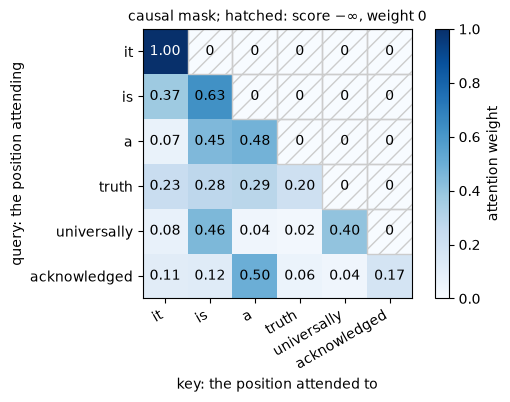

In [2]:
MASK = True
show_weights(MASK)

### Solution

In [3]:
switch(MASK, "MASK")
shown = np.round(weights(False), 2)  # the weights as the cells print them
ahead = ", ".join(f"{a:.2f}" for a in np.triu(shown, 1).sum(axis=1)[:-1])
kept = ", ".join(f"{a:.2f}" for a in np.tril(shown).sum(axis=1)[:-1])
display(Markdown(
    f"With the mask every weight on a later position is {np.triu(weights(True), 1).max():g}. "
    f"Without it, the weights the first {len(WORDS) - 1} positions put on later ones, each to two "
    f"decimals, add to {ahead}; zeroing them after the softmax leaves rows adding to {kept}."))

With the mask every weight on a later position is 0. Without it, the weights the first 5 positions put on later ones, each to two decimals, add to 0.61, 0.62, 0.40, 0.21, 0.03; zeroing them after the softmax leaves rows adding to 0.37, 0.38, 0.60, 0.79, 0.97.

## 2. Low dimensions turn fast and high dimensions slowly

The sinusoidal encoding puts a sine of the position on each even dimension and
a cosine on each odd one, and the frequency falls from one pair of dimensions
to the next. Run the cell, then set `POSITION` to 100 and run it again: from
which dimension on does the encoding stay near its values at position 0, 0 for
a sine and 1 for a cosine?

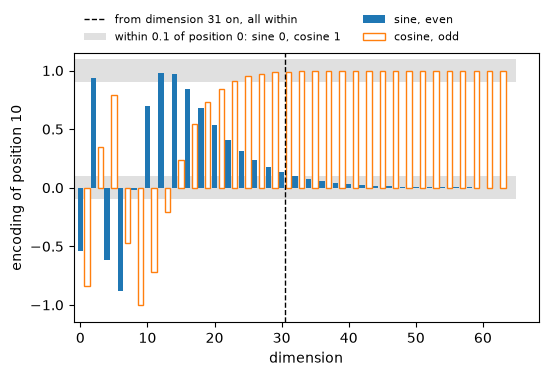

In [4]:
POSITION = 10
encoded = POSITION
show_encoding(encoded)

### Solution

In [5]:
pos = whole(encoded, "POSITION", 100000)
for p in (pos, 100 if pos != 100 else 10):
    k, near = still_from(p)
    display(Markdown(f"At position {p}, {near or 'none'} of the {D_MODEL} dimensions lie within "
                     f"{TOL} of their values at position 0; " + (f"all from dimension {k} up are "
                     "among them." if k < D_MODEL else "the last dimension is not among them.")))

At position 10, 38 of the 64 dimensions lie within 0.1 of their values at position 0; all from dimension 31 up are among them.

At position 100, 25 of the 64 dimensions lie within 0.1 of their values at position 0; all from dimension 47 up are among them.

## 3. Similarity between positions

The encodings of a position and of itself have cosine similarity 1. Run the
cell, then set `POSITION` to 60 and run it again: does the similarity of two
positions depend on where they sit, or only on how far apart they are?

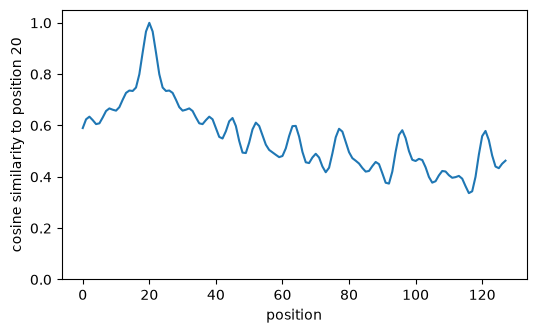

In [6]:
POSITION = 20
centre = POSITION
show_similarity(centre)

### Solution

In [7]:
pos = whole(centre, "POSITION", N_POS - 1)
other = 60 if pos != 60 else 20
offset = np.arange(-min(pos, other), N_POS - max(pos, other))  # the distances both positions reach
gap = np.abs(similarity(pos)[pos + offset] - similarity(other)[other + offset]).max()
display(Markdown(
    f"At every distance, the similarity to position {pos} equals the similarity to position "
    f"{other} to within {gap:.1g}: it depends on the distance alone, since each pair of dimensions"
    f" adds sin(pω)·sin(qω) + cos(pω)·cos(qω), which is cos((p − q)ω)."))

At every distance, the similarity to position 20 equals the similarity to position 60 to within 3e-16: it depends on the distance alone, since each pair of dimensions adds sin(pω)·sin(qω) + cos(pω)·cos(qω), which is cos((p − q)ω).

## Appendix. Residual connections and layer normalisation through twelve blocks

Each block holds one feed-forward sublayer, f(h) = W₂ · max(0, W₁ h), with
its own random W₁ of 256 by 64 entries and W₂ of 64 by 256, drawn with mean 0
and variances 1/64 and 1/256, one over the width each matrix reads; the
attention sublayer and the biases are left out. Layer normalisation rescales
the 64 components of x to mean 0 and variance 1,

LN(x) = (x − μ) / √(σ² + ε),

with its learned scale and shift at their initial values 1 and 0. With both
switches on, block l maps the signal xₗ to

xₗ₊₁ = xₗ + f(LN(xₗ)),

the pre-norm placement. Without the residual connection the block returns
f(LN(xₗ)), and without layer normalisation LN drops out. The chain rule gives
each block's Jacobian,

∂xₗ₊₁ / ∂xₗ = I + J_f · J_LN,

with J_f and J_LN the Jacobians of the sublayer and of the normalisation. A
gradient g at the output reaches the input as J₁ᵀ J₂ᵀ ⋯ J₁₂ᵀ g. Without the
residual connection the I drops out of every factor, and the gradient is a
product of twelve sublayer Jacobians.

One random input of 64 components passes through the twelve blocks under each
of the four combinations of the two switches, and its length is measured after
every block.

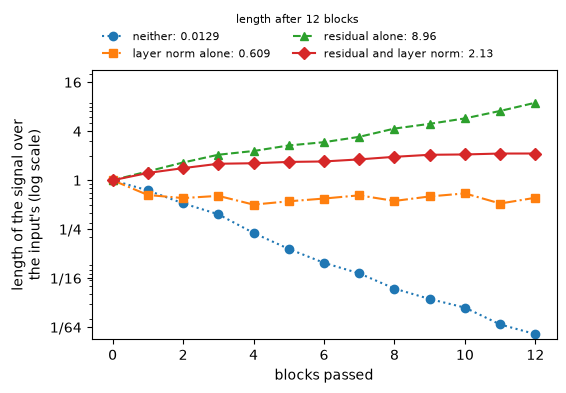

In [8]:
fig, ax = plt.subplots(figsize=(6, 3.5))
for (r, n), style in zip(SETUPS, ("o:", "s-.", "^--", "D-")):
    sizes = blocks(r, n)[0]
    ax.plot(range(DEPTH + 1), sizes, style, label=f"{SETUPS[r, n]}: {sizes[-1]:.3g}")
ax.set(yscale="log", yticks=2.0 ** np.arange(-6, 5, 2), ylim=(2 ** -6.5, 2 ** 4.5),
       yticklabels=["1/64", "1/16", "1/4", "1", "4", "16"], xticks=range(0, DEPTH + 1, 2),
       xlabel="blocks passed", ylabel="length of the signal over\nthe input's (log scale)")
ax.legend(loc="lower left", bbox_to_anchor=(0, 1), ncol=2, frameon=False, fontsize=8,
          title=f"length after {DEPTH} blocks", title_fontsize=8)
plt.show()

**Exercise.** Set `RESIDUAL` and `NORM` to each of their four combinations in
turn and rerun the cell. A gradient of length 1 arrives at the output: how
long is it at the input under each combination?

In [9]:
RESIDUAL = True
NORM = True

sizes, grad = blocks(RESIDUAL, NORM)
print(f"signal: {sizes[-1]:.3g} times the input's length; gradient at the input: {grad:.3g}")

signal: 2.13 times the input's length; gradient at the input: 2.82


### Solution

In [10]:
blocks(RESIDUAL, NORM)  # refuses the exercise's switches when either is not True or False
res = {k: blocks(*k) for k in SETUPS}
rows = "\n".join(f"| {SETUPS[k]} | {s[-1]:.3g} | {g:.3g} |" for k, (s, g) in res.items())
display(Markdown(
    f"| blocks with | signal after {DEPTH} blocks, over the input | gradient at the input, from "
    f"length 1 at the output |\n| --- | ---: | ---: |\n{rows}\n\n"
    f"In these {DEPTH} blocks the residual multiplies the gradient at the input by "
    f"{res[True, False][1] / res[False, False][1]:,.4g}, and layer norm added to the residual "
    f"multiplies it by {res[True, True][1] / res[True, False][1]:.3g}."))

| blocks with | signal after 12 blocks, over the input | gradient at the input, from length 1 at the output |
| --- | ---: | ---: |
| neither | 0.0129 | 0.00605 |
| layer norm alone | 0.609 | 0.456 |
| residual alone | 8.96 | 15.2 |
| residual and layer norm | 2.13 | 2.82 |

In these 12 blocks the residual multiplies the gradient at the input by 2,512, and layer norm added to the residual multiplies it by 0.185.